###  导入相关库

In [7]:
import torch
from torchinfo import summary
from torchvision.models import AlexNet,efficientnet  # 导入AlexNet官方模型
import netron  # 导入Netron库

原始的模型结构输出

In [2]:
model = AlexNet().to('cuda'if torch.cuda.is_available() else 'cpu')
print(model)    # 原始的打印模型结构

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

使用torchinfo打印模型结构和参数信息 torchinfo 的 summary 函数的 input_size 应该是一个元组或列表，表示输入张量的形状，而不是一个实际的张量。

In [3]:
summary(model, input_size=(64, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [64, 1000]                --
├─Sequential: 1-1                        [64, 256, 6, 6]           --
│    └─Conv2d: 2-1                       [64, 64, 55, 55]          23,296
│    └─ReLU: 2-2                         [64, 64, 55, 55]          --
│    └─MaxPool2d: 2-3                    [64, 64, 27, 27]          --
│    └─Conv2d: 2-4                       [64, 192, 27, 27]         307,392
│    └─ReLU: 2-5                         [64, 192, 27, 27]         --
│    └─MaxPool2d: 2-6                    [64, 192, 13, 13]         --
│    └─Conv2d: 2-7                       [64, 384, 13, 13]         663,936
│    └─ReLU: 2-8                         [64, 384, 13, 13]         --
│    └─Conv2d: 2-9                       [64, 256, 13, 13]         884,992
│    └─ReLU: 2-10                        [64, 256, 13, 13]         --
│    └─Conv2d: 2-11                      [64, 256, 13, 13]        

使用使用Netron库展示结构图，需要先将模型转换为.onnx格式文件

In [4]:
torch.onnx.export(model, torch.ones((1,3,224,224)).to('cuda'if torch.cuda.is_available() else 'cpu'), f='AlexNet.onnx')  #导出 .onnx 文件
netron.start('AlexNet.onnx')

Serving 'AlexNet.onnx' at http://localhost:8080


('localhost', 8080)

### Netron 模型图的解读

以efficientnet_b0为例，使用torchinfo库可视化模型结构。

In [ ]:
model = efficientnet.efficientnet_b0().to('cuda')  # 加载EfficientNet-B0模型到GPU
torch.onnx.export(model, torch.ones((1,3,224,224)).to('cuda'),"efficientnet_b0.onnx", opset_version=11)   #导出 .onnx 文件
netron.start('efficientnet_b0.onnx') #使用Netron库展示结构图

#### 模型中的Conv参数

##### Weights:

shape = (32, 3, 224, 224)

代表着该卷积层的输出通道有32个，需要的输入通道数为3，卷积核的尺寸为224x224。

注意：这里面的输入通道数需要和分组数相乘才等于上一层的输出通道数。

例如：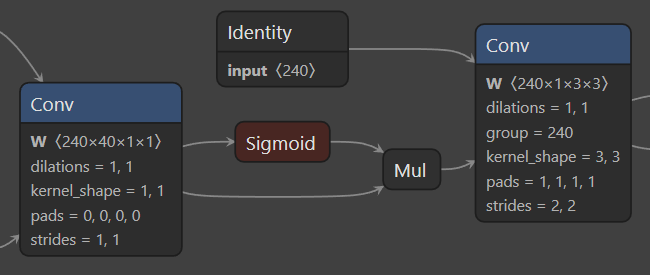

上图中的前一层输出通道数为240，由于采用了DW卷积，所以分组数目为240，也就是说卷积核所需要的输入通道数为1，共计240×1=240个实际输入通道数

##### Identity：
常常代表着卷积等操作的偏置数

##### Mul和Add：
是相乘和相加操作